# Week 3: Advanced Data Analysis and Visualization in Logistics

## Olist Logistics Data Analysis

This notebook performs advanced exploratory data analysis and visualization
of the cleaned Olist logistics dataset. The analysis focuses on delivery
performance, order activity, transportation-related costs, shipment
characteristics, distributions, correlations, and potential operational
bottlenecks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/processed/olist_logistics_cleaned.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 113425
Columns: 25


In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,on_time_delivery,product_id,seller_id,price,freight_value,total_item_cost,customer_city,customer_state,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.44,-7.11,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,0.00,0.02,38.71,sao paulo,SP,maua,SP,utilidades_domesticas,500.00,19.00,8.00,13.00,0.00,0.02
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.78,-5.36,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,0.02,0.06,141.46,barreiras,BA,belo horizonte,SP,perfumaria,400.00,19.00,13.00,19.00,0.02,0.06
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.39,-17.25,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,0.02,0.05,179.12,vianopolis,GO,guariba,SP,automotivo,420.00,24.00,19.00,21.00,0.02,0.05
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.21,-12.98,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,0.01,0.07,72.20,sao goncalo do amarante,RN,belo horizonte,MG,pet_shop,450.00,30.00,10.00,20.00,0.01,0.07
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.87,-9.24,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,0.00,0.02,28.62,santo andre,SP,mogi das cruzes,SP,papelaria,250.00,51.00,15.00,15.00,0.00,0.02


In [4]:
df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,on_time_delivery,product_id,seller_id,price,freight_value,total_item_cost,customer_city,customer_state,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,22.19,-1.27,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,0.03,0.05,195.00,praia grande,SP,tupa,SP,bebes,4950.00,40.00,10.00,40.00,0.03,0.05
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,24.86,-5.52,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,0.03,0.16,271.01,nova vicosa,BA,sao paulo,SP,eletrodomesticos_2,13300.00,32.00,90.00,22.00,0.03,0.16
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,17.09,-20.02,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,0.03,0.10,220.58,japuiba,RJ,ilicinea,MG,informatica_acessorios,6550.00,20.00,20.00,20.00,0.03,0.10
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,17.09,-20.02,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,0.03,0.10,220.58,japuiba,RJ,ilicinea,MG,informatica_acessorios,6550.00,20.00,20.00,20.00,0.03,0.10
113424,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-16 13:08:30,2018-04-03,7.67,-17.45,1,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,0.01,0.04,86.86,lapa,PR,franca,SP,beleza_saude,150.00,16.00,7.00,15.00,0.01,0.04


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_delivered_customer_date  110196 non-null  str    
 5   order_estimated_delivery_date  113425 non-null  str    
 6   delivery_time_days             110196 non-null  float64
 7   delivery_delay_days            110196 non-null  float64
 8   on_time_delivery               113425 non-null  int64  
 9   product_id                     112650 non-null  str    
 10  seller_id                      112650 non-null  str    
 11  price                          112650 non-null  float64
 12  freight_value                  112650 non

In [6]:
df.describe()

,delivery_time_days,delivery_delay_days,on_time_delivery,price,freight_value,total_item_cost,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized
count,110196.00,110196.00,113425.00,112650.00,112650.00,112650.00,113425.00,113425.00,113425.00,113425.00,112650.00,112650.00
mean,12.47,-11.33,0.89,0.02,0.05,140.64,2083.93,30.12,16.57,22.98,0.02,0.05
std,9.45,10.16,0.31,0.03,0.04,190.72,3740.26,16.10,13.40,11.67,0.03,0.04
min,0.53,-146.02,0.00,0.00,0.00,6.08,0.00,7.00,2.00,6.00,0.00,0.00
25%,6.74,-16.32,1.00,0.01,0.03,55.22,300.00,18.00,8.00,15.00,0.01,0.03
50%,10.18,-12.05,1.00,0.01,0.04,92.32,700.00,25.00,13.00,20.00,0.01,0.04
75%,15.54,-6.48,1.00,0.02,0.05,157.94,1800.00,38.00,20.00,30.00,0.02,0.05
max,209.63,188.98,1.00,1.00,1.00,6929.31,40425.00,105.00,105.00,118.00,1.00,1.00


In [7]:
print("Columns in the dataset:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:
1. order_id
2. customer_id
3. order_status
4. order_purchase_timestamp
5. order_delivered_customer_date
6. order_estimated_delivery_date
7. delivery_time_days
8. delivery_delay_days
9. on_time_delivery
10. product_id
11. seller_id
12. price
13. freight_value
14. total_item_cost
15. customer_city
16. customer_state
17. seller_city
18. seller_state
19. product_category_name
20. product_weight_g
21. product_length_cm
22. product_height_cm
23. product_width_cm
24. price_normalized
25. freight_normalized


## 2. Data Quality Assessment

Before performing statistical analysis and visualization, the cleaned
dataset is examined for missing values, duplicate records, data types,
and basic statistical characteristics. This ensures that the analysis
is based on reliable and properly structured data.

In [8]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    3229
order_estimated_delivery_date       0
delivery_time_days               3229
delivery_delay_days              3229
on_time_delivery                    0
product_id                        775
seller_id                         775
price                             775
freight_value                     775
total_item_cost                   775
customer_city                       0
customer_state                      0
seller_city                       775
seller_state                      775
product_category_name               0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
price_normalized                  775
freight_normalized                775
dtype: int64


In [9]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 10225


In [10]:
# Check data types
print("Data types:")
print(df.dtypes)

Data types:
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_delivered_customer_date        str
order_estimated_delivery_date        str
delivery_time_days               float64
delivery_delay_days              float64
on_time_delivery                   int64
product_id                           str
seller_id                            str
price                            float64
freight_value                    float64
total_item_cost                  float64
customer_city                        str
customer_state                       str
seller_city                          str
seller_state                         str
product_category_name                str
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
price_normalized                 float64
frei

In [11]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 113425
Number of columns: 25


## 3. Date and Time Preparation

The order purchase date, actual delivery date, and estimated delivery
date are converted into datetime format. These variables are important
for analyzing delivery performance and identifying temporal patterns.

In [12]:
# Convert date columns to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

print(df[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


## 4. Central Tendency and Descriptive Statistics

Descriptive statistics are used to understand the central tendency and
spread of important logistics variables. Mean, median, standard deviation,
minimum, and maximum values are calculated for delivery performance,
cost, shipment, and product-related variables.

In [13]:
# Select important numerical logistics variables
analysis_columns = [
    "delivery_time_days",
    "delivery_delay_days",
    "price",
    "freight_value",
    "total_item_cost",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "price_normalized",
    "freight_normalized"
]

# Descriptive statistics
descriptive_stats = df[analysis_columns].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
delivery_time_days,110196.00,12.47,9.45,0.53,6.74,10.18,15.54,209.63
delivery_delay_days,110196.00,-11.33,10.16,-146.02,-16.32,-12.05,-6.48,188.98
price,112650.00,0.02,0.03,0.00,0.01,0.01,0.02,1.00
freight_value,112650.00,0.05,0.04,0.00,0.03,0.04,0.05,1.00
total_item_cost,112650.00,140.64,190.72,6.08,55.22,92.32,157.94,6929.31
product_weight_g,113425.00,2083.93,3740.26,0.00,300.00,700.00,1800.00,40425.00
product_length_cm,113425.00,30.12,16.10,7.00,18.00,25.00,38.00,105.00
product_height_cm,113425.00,16.57,13.40,2.00,8.00,13.00,20.00,105.00
product_width_cm,113425.00,22.98,11.67,6.00,15.00,20.00,30.00,118.00
price_normalized,112650.00,0.02,0.03,0.00,0.01,0.01,0.02,1.00


In [14]:
central_tendency = pd.DataFrame({
    "Mean": df[analysis_columns].mean(),
    "Median": df[analysis_columns].median(),
    "Standard Deviation": df[analysis_columns].std()
})

central_tendency

,Mean,Median,Standard Deviation
delivery_time_days,12.47,10.18,9.45
delivery_delay_days,-11.33,-12.05,10.16
price,0.02,0.01,0.03
freight_value,0.05,0.04,0.04
total_item_cost,140.64,92.32,190.72
product_weight_g,2083.93,700.00,3740.26
product_length_cm,30.12,25.00,16.10
product_height_cm,16.57,13.00,13.40
product_width_cm,22.98,20.00,11.67
price_normalized,0.02,0.01,0.03


In [15]:
delivery_stats = df[
    [
        "delivery_time_days",
        "delivery_delay_days"
    ]
].describe().T

delivery_stats

,count,mean,std,min,25%,50%,75%,max
delivery_time_days,110196.00,12.47,9.45,0.53,6.74,10.18,15.54,209.63
delivery_delay_days,110196.00,-11.33,10.16,-146.02,-16.32,-12.05,-6.48,188.98


In [16]:
print("Average delivery time:",
      round(df["delivery_time_days"].mean(), 2), "days")

print("Median delivery time:",
      round(df["delivery_time_days"].median(), 2), "days")

print("Average delivery delay:",
      round(df["delivery_delay_days"].mean(), 2), "days")

Average delivery time: 12.47 days
Median delivery time: 10.18 days
Average delivery delay: -11.33 days


In [17]:
df["on_time_delivery"].value_counts()

on_time_delivery
1    101481
0     11944
Name: count, dtype: int64

In [18]:
on_time_percentage = (
    df["on_time_delivery"]
    .value_counts(normalize=True) * 100
)

on_time_percentage

on_time_delivery
1   89.47
0   10.53
Name: proportion, dtype: float64

In [19]:
print("On-time delivery percentage:")
print(on_time_percentage)

On-time delivery percentage:
on_time_delivery
1   89.47
0   10.53
Name: proportion, dtype: float64


## 5. Distribution of Delivery Time

The distribution of delivery time is analyzed to understand how long
shipments typically take to reach customers and whether the dataset
contains unusually long or short delivery durations.

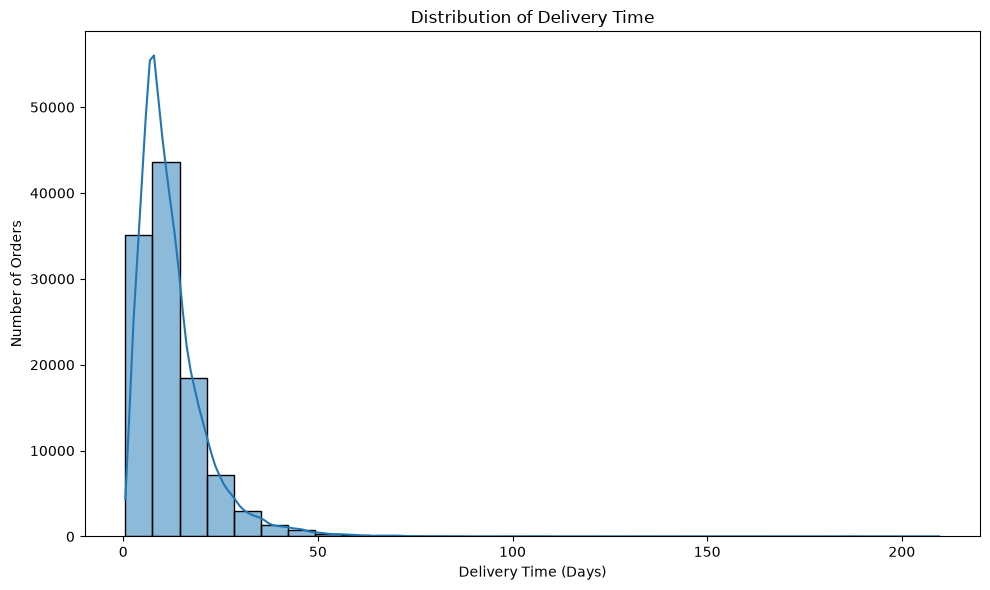

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="delivery_time_days",
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig(
    "../screenshots/week3_delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Distribution of Delivery Delays

Delivery delay is examined to determine how frequently orders experience
delays and how large those delays are. This can help identify potential
delivery performance problems.

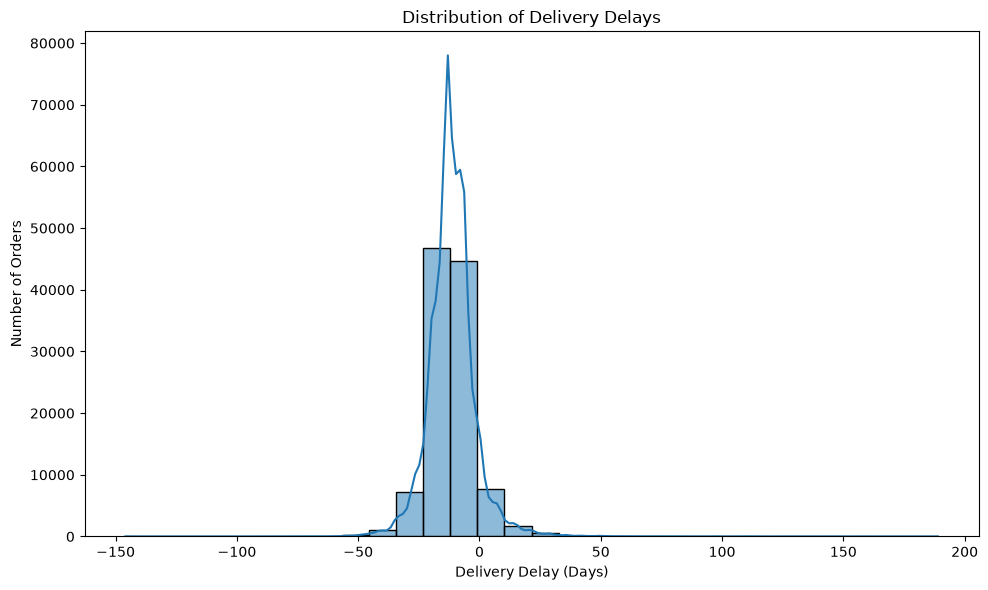

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="delivery_delay_days",
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig(
    "../screenshots/week3_delivery_delay_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()